<a href="https://www.kaggle.com/code/ahmedfakhar123/ml-lab-01-end-to-end-machine-learning-project?scriptVersionId=338999150" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

---
# 💻 ML Lab 01 — End-to-End Machine Learning Project

### ***Build a Student Placement Prediction Model from Scratch***
---


> Welcome to the first notebook in the **Machine Learning Labs** series! 🚀
>
> In this hands-on lab, you'll build a complete **end-to-end Machine Learning project** using a **Student Placement Prediction** dataset. Instead of focusing only on algorithms, you'll experience the entire machine learning workflow—from understanding the problem and exploring the data to training, evaluating, and saving a predictive model.

<div align="center">
    <img src="https://daxg39y63pxwu.cloudfront.net/images/blog/end-to-end-machine-learning-project/Building_an_end-to-end_machine_learning_project.webp" width=500 />
    <img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcSPOyJ9hSS4ts-pLtVhs9VEzFLamJfvvXN1jAJMxiZ0ug&s=10" width=500 />
</div>

<br>

Unlike the [**🤖 Machine Learning Foundations**](https://www.kaggle.com/work/collections/18832082) series, which explains the theory behind ML concepts, the [**🔬 Machine Learning Lab**](https://www.kaggle.com/work/collections/18848042) series is all about **learning by doing**. Every notebook is designed to help you gain practical experience with the tools, libraries, and workflows used by Machine Learning Engineers in real-world projects.

By completing this lab, you'll understand how different stages of the **Machine Learning Development Life Cycle (MLDLC)** come together to build an intelligent application.

---
# 🔄 ML lifecycle Stages

In this notebook, we'll see **how a complete end-to-end Machine Learning project is built** by following the standard **Machine Learning Development Life Cycle (MLDLC)** used in real-world ML projects.

* Problem Definition
* Data Collection
* EDA
* Data Preprocessing
* Feature Engineering
* Model Training
* Evaluation
* Deployment

By the end of this notebook, you'll understand how these stages come together to create a complete Machine Learning pipeline and gain practical experience building your **first end-to-end ML project** using Python and Scikit-Learn. 🚀

---
# 1️⃣ Problem Definition

In this project, we'll build a **Machine Learning model** to predict whether a student will be **placed** based on their academic information.

## 1.1 Problem Statement

> **Predict whether a student will be placed or not placed.**

## 1.2 Problem Type

- **Machine Learning Task:** Supervised Learning
- **Type:** Binary Classification
- **Target Variable:** `placement`

The final model will predict one of two outcomes:

- ✅ Placed
- ❌ Not Placed

---
# 2️⃣ Data Collection

Data is the foundation of every Machine Learning project. In this lab, we'll use a **Student Placement Prediction** dataset that contains information about students' academic performance and their placement status.

We'll begin by:

- 📦 Importing the required libraries
- 📥 Loading the dataset into a Pandas DataFrame
- 👀 Viewing the first few rows to understand its structure

Let's load the dataset and take our first look at the data.

## 2.1 Importing Libraries

In [1]:
# For Data Manipulation
import numpy as np
import pandas as pd

# For Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

## 2.2 Loading Dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/abhasmalguri/placement/placement (1).csv")

## 2.3 Viewing First Few Rows

In [3]:
df.head()

,cgpa,resume_score,placed
0,8.14,6.52,1
1,6.17,5.17,0
2,8.27,8.86,1
3,6.88,7.27,1
4,7.52,7.30,1


---
# 3️⃣ Exploratory Data Analysis (EDA)

Before training a Machine Learning model, it's important to understand the dataset. This process is called **Exploratory Data Analysis (EDA)**.

EDA helps us explore the data, identify patterns, detect missing values, check for outliers, and understand the relationships between features.

## 3.1 Dataset Shape

In [4]:
df.shape

(100, 3)

## 3.2 Dataset Information

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   cgpa          100 non-null    float64
 1   resume_score  100 non-null    float64
 2   placed        100 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 2.5 KB


## 3.3 Visualize Feature Distributions

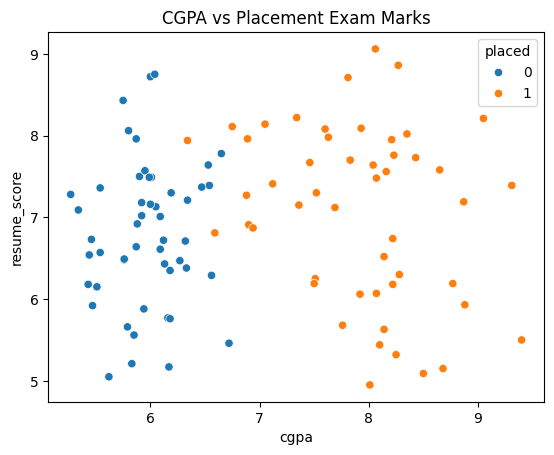

In [6]:
sns.scatterplot(
    data=df,
    x="cgpa",
    y="resume_score",
    hue="placed"
)

plt.title("CGPA vs Placement Exam Marks")
plt.show()

## 3.4 Analyze correlations

<Axes: >

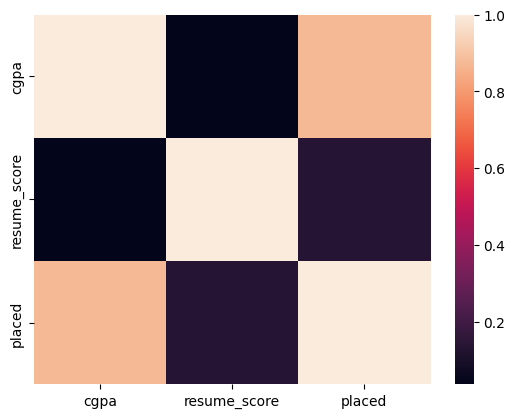

In [7]:
sns.heatmap(df.corr(numeric_only=True))

---
# 4️⃣ Data Preprocessing

Raw data is rarely ready for Machine Learning. Before training a model, we need to prepare the dataset by selecting the input features, separating the target variable, splitting the data into training and testing sets, and scaling the features.

In this section, we will:

- 🎯 Separate features and target
- ✂️ Split the dataset into training and testing sets
- 📏 Scale the numerical features using StandardScaler

After preprocessing, the data will be ready for model training.

## 4.1 Separate Features and Target

In [8]:
student_features = ["cgpa", "resume_score"]

By convention, this data is features called X.

In [9]:
X = df[student_features]

Let's quickly review the data we'll be using to predict `placed` using the describe method and the head method, which shows the top few rows.

In [10]:
X.describe()

,cgpa,resume_score
count,100.0000,100.000000
mean,6.9422,6.930500
std,1.1192,0.979608
min,5.2700,4.950000
25%,5.9800,6.190000
50%,6.6200,7.055000
75%,8.0450,7.640000
max,9.4000,9.060000


In [11]:
X.head()

,cgpa,resume_score
0,8.14,6.52
1,6.17,5.17
2,8.27,8.86
3,6.88,7.27
4,7.52,7.30


By convention, the prediction target is called y.

In [12]:
y = df.placed
y

0     1
1     0
2     1
3     1
4     1
     ..
95    0
96    1
97    0
98    1
99    0
Name: placed, Length: 100, dtype: int64

## 4.2 Training and Testing Sets
The scikit-learn library has a function `train_test_split` to break up the data into two pieces. We'll use some of that data as training data to fit the model.

In [13]:
from sklearn.model_selection import train_test_split

train_X, val_X, train_y, val_y = train_test_split(X, y, test_size=0.1)

## 4.3 Scale the numerical features

In [14]:
from sklearn.preprocessing import StandardScaler

scale = StandardScaler()

train_X = scale.fit_transform(train_X)
train_X

array([[-0.84912296,  0.21972493],
       [ 1.03555795,  2.27401488],
       [ 0.61470687,  1.21443375],
       [ 0.90747284, -0.96960083],
       [-0.19039953, -1.61832397],
       [ 1.10874944, -0.47224642],
       [ 0.01087707, -0.09382459],
       [-0.67529316,  0.37109366],
       [-1.33401659, -1.12096956],
       [ 0.37683453,  1.36580248],
       [ 1.04470689, -0.95878878],
       [-1.45295276,  0.14404056],
       [ 0.48662176,  0.7711396 ],
       [ 0.53236645, -0.76417183],
       [-0.73018678, -0.56955489],
       [ 1.23683455, -0.71011157],
       [ 1.12704732,  0.65220703],
       [ 1.30087711,  1.14956144],
       [-1.03210169,  1.19280964],
       [-0.55635699, -0.26681743],
       [-0.92231445,  0.0683562 ],
       [ 2.17917501,  0.46840214],
       [-0.96805913,  1.08468912],
       [-0.84912296,  1.9064051 ],
       [ 2.26151543, -1.57507576],
       [-0.54720805, -0.62361515],
       [ 0.80683454,  1.89559305],
       [-1.06869743, -0.50468258],
       [ 0.82513241,

In [15]:
val_X = scale.fit_transform(val_X)
val_X

array([[ 0.92484082, -1.04182312],
       [-0.84496464,  0.60355983],
       [ 1.41819367, -0.57929612],
       [-1.19735954, -0.09402188],
       [ 0.89351683,  0.95235068],
       [-1.03290859,  1.31630636],
       [ 0.94050282,  1.64234998],
       [-0.95459861, -0.85984528],
       [-0.88411963, -0.61720817],
       [ 0.73689688, -1.32237229]])